In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 50000  # מספר העסקאות

# מזהי משתמשים 
user_ids = np.random.randint(1, 10001, size=n)

# סכום עסקה
transaction_amount = np.round(np.random.exponential(scale=50, size=n) + 5, 2)  # רוב העסקאות קטנות, מעט גבוהות

# תאריך עסקה בטווח של שנה
start_date = datetime(2024, 1, 1)
end_date   = datetime(2024, 12, 31)
date_range_days = (end_date - start_date).days

transaction_dates = [
    start_date + timedelta(days=int(x))
    for x in np.random.randint(0, date_range_days, size=n)
]

# שעה ביום (0–23)
transaction_hour = np.random.randint(0, 24, size=n)

# מדינות 
countries = ["IL", "US", "UK", "DE", "FR", "IN", "CN", "BR", "NG"]
country_probs = [0.5, 0.1, 0.08, 0.06, 0.06, 0.06, 0.05, 0.05, 0.04]
transaction_country = np.random.choice(countries, size=n, p=country_probs)

# סוג מכשיר
device_types = ["ios", "android", "web"]
device_probs = [0.45, 0.45, 0.10]
device_type = np.random.choice(device_types, size=n, p=device_probs)

# קטגוריית בית העסק
merchant_categories = ["food", "gaming", "crypto", "ecommerce", "travel", "subscription", "utilities"]
merchant_probs =       [0.25,   0.15,     0.10,    0.20,       0.10,      0.10,          0.10]
merchant_category = np.random.choice(merchant_categories, size=n, p=merchant_probs)

# מרחק בין המיקום האחרון של המשתמש למיקום העסק (בק"מ), מדמה נסיעות/VPN
location_distance_km = np.round(np.random.exponential(scale=5, size=n), 2)

# ציון סיכון IP (0–1), גבוה = חשוד
ip_risk_score = np.round(np.random.beta(a=2, b=5, size=n), 3)  # רוב הבקשות לגיטימיות, מעט מסוכנות

# מהירות עסקאות: כמה עסקאות היו לאותו user ב-24 השעות האחרונות (סימולציה)
user_transaction_velocity = np.random.poisson(lam=0.5, size=n)  # רוב המשתמשים לא עושים הרבה ביממה

# fingerprint של מכשיר (נשתמש בזה רק כתכונה קטגוריאלית – high_risk / normal)
device_fingerprint = np.random.choice(
    ["normal", "high_risk"],
    size=n,
    p=[0.95, 0.05]  # רוב המכשירים לגיטימיים, מעט חשודים
)

# בעבר נרשמה הונאה לאותו משתמש (0/1)
past_fraud_flag = np.random.choice(
    [0, 1],
    size=n,
    p=[0.97, 0.03]  # מעט משתמשים עם היסטוריה בעייתית
)

# בסיס הסתברות להונאה (נבנה לוגית)
base_prob = 0.01  # 1% הונאה בסיסית

fraud_prob = (
    base_prob
    + 0.02 * (transaction_amount > 500)  # עסקאות גדולות יותר חשודות
    + 0.03 * (transaction_hour < 5)      # עסקאות בשעות לילה
    + 0.03 * (transaction_country != "IL")  # עסקאות מחו"ל
    + 0.04 * (ip_risk_score > 0.7)
    + 0.03 * (user_transaction_velocity > 3)
    + 0.05 * (device_fingerprint == "high_risk")
    + 0.06 * (past_fraud_flag == 1)
)

# הגבלת הסתברויות ל-0–0.95
fraud_prob = np.clip(fraud_prob, 0, 0.95)

# קביעת is_fraud לפי ההסתברות (הגרלה בינארית)
is_fraud = (np.random.rand(n) < fraud_prob).astype(int)

# בניית DataFrame
df_fraud = pd.DataFrame({
    "user_id": user_ids,
    "transaction_amount": transaction_amount,
    "transaction_date": transaction_dates,
    "transaction_hour": transaction_hour,
    "transaction_country": transaction_country,
    "device_type": device_type,
    "merchant_category": merchant_category,
    "location_distance_km": location_distance_km,
    "ip_risk_score": ip_risk_score,
    "user_transaction_velocity": user_transaction_velocity,
    "device_fingerprint": device_fingerprint,
    "past_fraud_flag": past_fraud_flag,
    "is_fraud": is_fraud
})

df_fraud.head()


,user_id,transaction_amount,transaction_date,transaction_hour,transaction_country,device_type,merchant_category,location_distance_km,ip_risk_score,user_transaction_velocity,device_fingerprint,past_fraud_flag,is_fraud
0,7271,43.04,2024-08-08,12,IL,android,food,5.49,0.139,1,high_risk,0,0
1,861,10.04,2024-03-05,19,IL,ios,crypto,3.39,0.164,2,high_risk,0,0
2,5391,53.29,2024-10-04,7,IL,android,subscription,3.55,0.222,1,normal,0,0
3,5192,149.13,2024-07-05,11,US,ios,ecommerce,1.57,0.239,0,normal,0,0
4,5735,69.13,2024-12-11,10,IL,android,ecommerce,21.09,0.077,0,normal,0,0


In [3]:
df_fraud.to_csv("fintech_fraud_dataset.csv", index=False)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# X = כל הפיצ׳רים, y = האם הונאה
X = df_fraud.drop(columns=["is_fraud", "transaction_date"])
y = df_fraud["is_fraud"]

# עמודות קטגוריאליות
categorical = ["transaction_country", "device_type", "merchant_category", "device_fingerprint"]

# עמודות מספריות
numeric = [col for col in X.columns if col not in categorical]

# Pipeline לעיבוד נתונים
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop="first"), categorical)
    ]
)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((37500, 11), (12500, 11))

In [7]:
from sklearn.linear_model import LogisticRegression

model_log = Pipeline(steps=[
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced'))

])

model_log.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_log = model_log.predict(X_test)

print("Confusion Matrix – Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report – Logistic Regression")
print(classification_report(y_test, y_pred_log))


Confusion Matrix – Logistic Regression
[[7464 4577]
 [ 183  276]]

Classification Report – Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.62      0.76     12041
           1       0.06      0.60      0.10       459

    accuracy                           0.62     12500
   macro avg       0.52      0.61      0.43     12500
weighted avg       0.94      0.62      0.73     12500



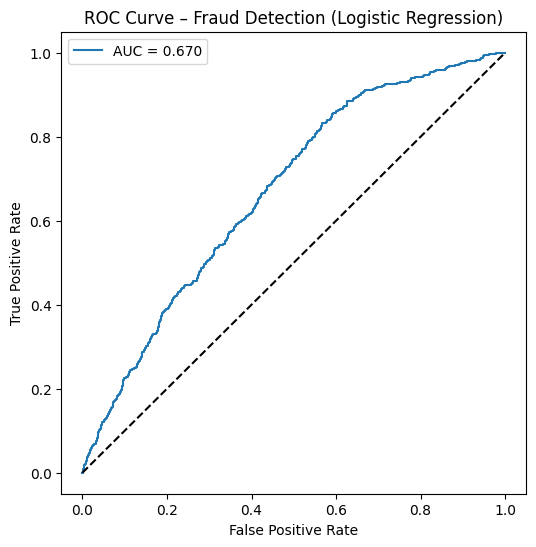

In [9]:


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_log = model_log.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Fraud Detection (Logistic Regression)")
plt.legend()
plt.show()


In [23]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"   
    ))
])

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix – Random Forest (balanced):")
print(confusion_matrix(y_test, y_pred_rf))



Confusion Matrix – Random Forest (balanced):
[[12041     0]
 [  459     0]]


In [25]:
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

threshold = 0.1  # ב0.1 המודל לא זיהה שום הונאה
y_pred_thresh = (y_prob_rf >= threshold).astype(int)

print("Classification Report – RF (threshold=0.1):")
print(classification_report(y_test, y_pred_thresh))


Classification Report – RF (threshold=0.1):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     12041
           1       0.06      0.09      0.07       459

    accuracy                           0.91     12500
   macro avg       0.51      0.52      0.51     12500
weighted avg       0.93      0.91      0.92     12500



In [26]:
import numpy as np

# שמות הפיצ’רים לאחר preprocess
onehot_features = list(
    model_rf.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out()
)

feature_names = numeric + onehot_features

# Feature importance מה-Random Forest
importances = model_rf.named_steps["rf"].feature_importances_

# מיון לפי חשיבות
indices = np.argsort(importances)[::-1]

print("Top 15 Important Features:\n")
for i in range(15):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")


Top 15 Important Features:

transaction_amount: 0.1494
user_id: 0.1483
location_distance_km: 0.1476
ip_risk_score: 0.1464
transaction_hour: 0.1251
transaction_country_IL: 0.0462
user_transaction_velocity: 0.0370
device_fingerprint_normal: 0.0244
device_type_ios: 0.0202
past_fraud_flag: 0.0188
merchant_category_food: 0.0147
merchant_category_ecommerce: 0.0139
merchant_category_gaming: 0.0123
device_type_web: 0.0114
merchant_category_utilities: 0.0110


C:\Users\Ilaya\AppData\Local\Temp\ipykernel_11908\56104126.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


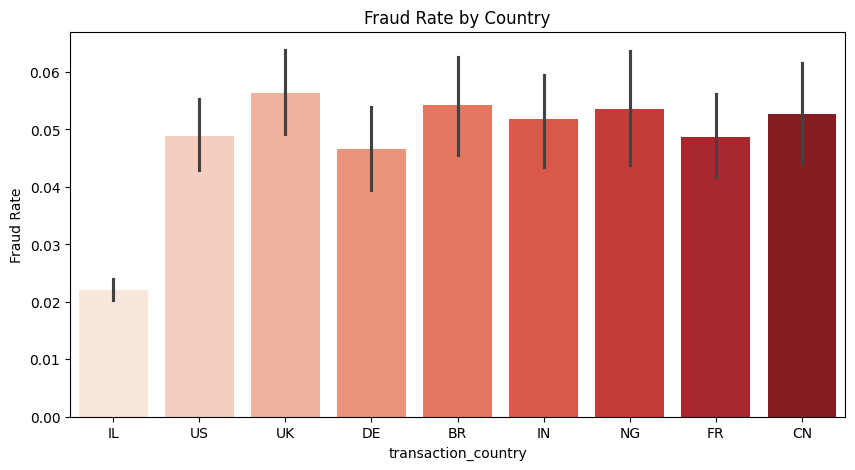

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
sns.barplot(
    x=df_fraud["transaction_country"],
    y=df_fraud["is_fraud"],
    estimator='mean',
    palette="Reds"
)
plt.title("Fraud Rate by Country")
plt.ylabel("Fraud Rate")
plt.show()


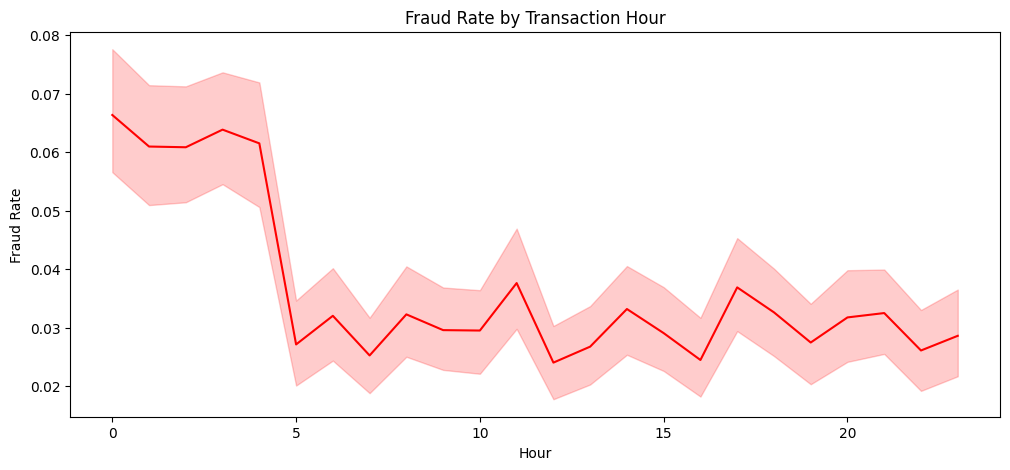

In [30]:
plt.figure(figsize=(12,5))
sns.lineplot(
    x=df_fraud["transaction_hour"],
    y=df_fraud["is_fraud"],
    estimator='mean',
    color="red"
)
plt.title("Fraud Rate by Transaction Hour")
plt.ylabel("Fraud Rate")
plt.xlabel("Hour")
plt.show()


C:\Users\Ilaya\AppData\Local\Temp\ipykernel_11908\3550789048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


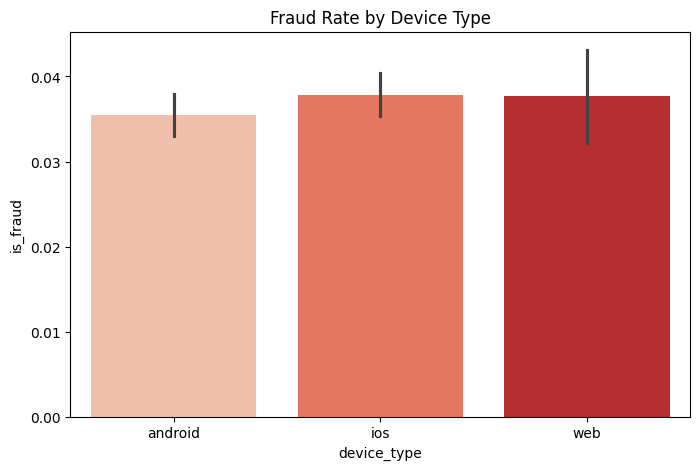

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=df_fraud["device_type"],
    y=df_fraud["is_fraud"],
    estimator='mean',
    palette="Reds"
)
plt.title("Fraud Rate by Device Type")
plt.show()


C:\Users\Ilaya\AppData\Local\Temp\ipykernel_11908\2357071207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


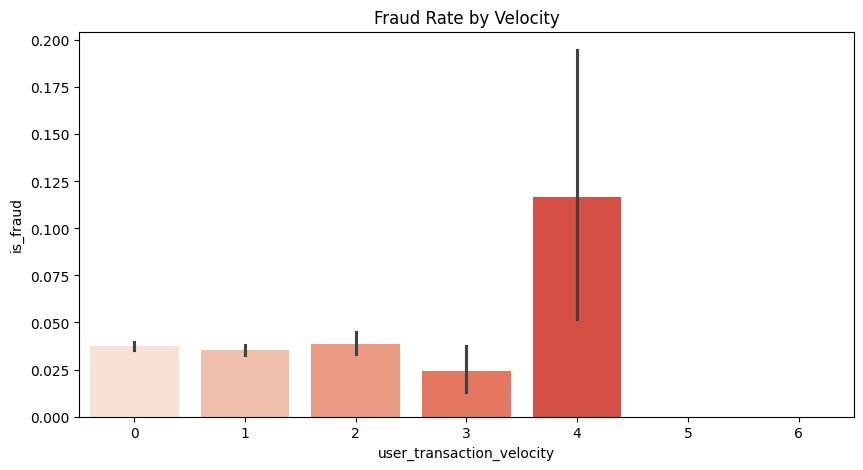

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=df_fraud["user_transaction_velocity"],
    y=df_fraud["is_fraud"],
    estimator='mean',
    palette="Reds"
)
plt.title("Fraud Rate by Velocity")
plt.show()